# 07 · Mule-account and transaction-network analytics
Nodes are accounts, edges are aggregated transfers. Full-period metrics are **descriptive**; detection uses only
28-day point-in-time windows. High connectivity alone is not treated as mule evidence.

In [1]:
import sys, json, sqlite3
from pathlib import Path
ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
sys.path.insert(0, str(ROOT))
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from src import config
pd.set_option("display.width", 180); pd.set_option("display.max_columns", 30); pd.set_option("display.precision", 4)
T = lambda name: pd.read_csv(config.TABLES_DIR / f"{name}.csv")
KM = json.loads((config.TABLES_DIR / "key_metrics.json").read_text())
con = sqlite3.connect(config.DB_PATH)
def show(fig_name, width=11):
    img = plt.imread(config.FIGURES_DIR / f"{fig_name}.png")
    h, w = img.shape[:2]
    fig, ax = plt.subplots(figsize=(width, width * h / w)); ax.imshow(img); ax.axis("off")
print("outputs loaded from", config.TABLES_DIR.relative_to(ROOT))

outputs loaded from outputs/tables


In [2]:
T("network_summary")

,metric,value
0,nodes (accounts with >=1 non-self transfer),19980
1,edges (distinct directed account pairs),117326
2,density,0.0002939172216913846
3,weakly connected components,1
4,largest weakly connected component (nodes),19980
5,largest strongly connected component (nodes),19802
6,reciprocity (share of edges with reverse edge),0.00519918858565024
7,in-degree mean / max,5.87 / 172
8,out-degree mean / max,5.87 / 203
9,labelled accounts in graph,1804


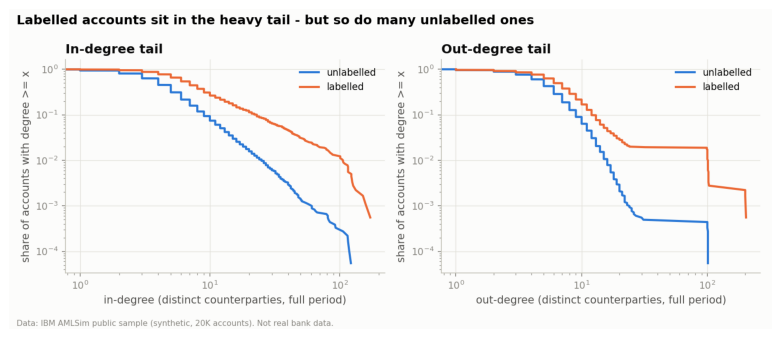

In [3]:
show("fig07_degree_distribution")

**Which network positions concentrate labelled accounts, and does centrality add anything beyond degree?**

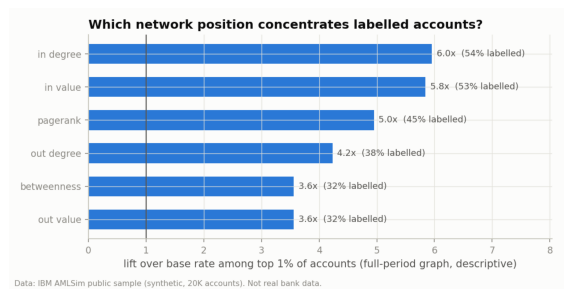

,metric,top_share,accounts,labelled_rate_top,base_rate,lift
0,in_degree,0.01,199,0.5377,0.0903,5.9551
1,out_degree,0.01,199,0.3819,0.0903,4.2298
2,in_value,0.01,199,0.5276,0.0903,5.8438
3,out_value,0.01,199,0.3216,0.0903,3.5619
4,pagerank,0.01,199,0.4472,0.0903,4.9533
5,betweenness,0.01,199,0.3216,0.0903,3.5619


In [4]:
show("fig08_centrality_lift", 8)
T("centrality_lift_top1pct")

In [5]:
cent = T("network_centrality_full_period")
cent[["in_degree", "out_degree", "in_value", "pagerank", "betweenness"]].corr(method="spearman").round(2)

,in_degree,out_degree,in_value,pagerank,betweenness
in_degree,1.00,0.52,0.93,0.86,0.66
out_degree,0.52,1.00,0.48,0.42,0.62
in_value,0.93,0.48,1.00,0.80,0.61
pagerank,0.86,0.42,0.80,1.00,0.62
betweenness,0.66,0.62,0.61,0.62,1.00


### Circular flows (time-respecting cycles of 3-6 accounts within 28-day windows)

In [6]:
cy = T("temporal_cycles_full_period")
print(len(cy), "cycles;", "length distribution:", cy.length.value_counts().sort_index().to_dict())
print(f"labelled accounts on a cycle: {KM['cycle_rate_labelled']:.4f}; unlabelled: {KM['cycle_rate_unlabelled']:.4f}")

47 cycles; length distribution: {3: 19, 4: 13, 5: 11, 6: 4}
labelled accounts on a cycle: 0.0377; unlabelled: 0.0023


### Potential mule-account candidates (held-out accounts, test weeks)
Candidate = at least two DISTINCT mule-relevant signals: fan-in collector (NET-01), fan-out distributor (NET-02),
rapid pass-through (AML-01), circular flow (AML-03), new-counterparty burst (BEH-02).

In [7]:
m = T("mule_candidates_heldout_test")
print(len(m), "candidates; share labelled:", round(m.is_suspicious.mean(), 3), "; base rate:", round(KM["heldout_test_base_rate"], 3))
m.groupby("pattern").agg(candidates=("account_id", "size"), labelled_rate=("is_suspicious", "mean"))

85 candidates; share labelled: 0.494 ; base rate: 0.092


,candidates,labelled_rate
pattern,,
circular-flow member,5,0.4000
collector,33,0.4848
collector-forwarder,12,0.9167
other combination,18,0.3889
pass-through,17,0.3529


### Case studies (selected by rule, see `src/case_studies.py`)

In [8]:
cases = json.loads((config.TABLES_DIR / "case_studies.json").read_text())
pd.DataFrame([{k: c[k] for k in ("case", "account_id", "label_is_suspicious", "max_risk_score", "priority",
               "weeks_alerted")} | {"signals": ", ".join(s.split()[0] for s in c["signals_fired_any_test_week"])}
              for c in cases])

,case,account_id,label_is_suspicious,max_risk_score,priority,weeks_alerted,signals
0,Case 1 - highest-priority labelled account,9998,1,100.00,CRITICAL,7,"AML-01, AML-03, BEH-02, NET-01, NET-02, NET-03, TXN-01, VEL-01"
1,Case 2 - potential mule-account candidate,19743,1,99.41,MEDIUM,1,"AML-01, BEH-02, NET-02, NET-03, VEL-01"
2,Case 3 - circular flow,11887,1,99.68,MEDIUM,1,"AML-03, BEH-01, NET-03, VEL-01"
3,Case 4 - unusual but not labelled,19994,0,99.86,HIGH,8,"AML-01, AML-03, BEH-02, NET-01, NET-02, NET-03, TXN-01, VEL-01"
4,Case 5 - borderline alert,13255,1,99.00,LOW,1,"BEH-01, VEL-01"
5,Case 6 - missed labelled account,9904,1,0.58,no alert,0,


In [9]:
for c in cases:
    print(f"== {c['case']} (account {c['account_id']})\n{c['interpretation']}\n")

== Case 1 - highest-priority labelled account (account 9998)
Account is labelled as a typology participant. Peak week 14 scored 100.0 (priority 'CRITICAL'), alerted in 7 of 9 active test weeks. Signals fired: Rapid pass-through, Circular flow, New-counterparty burst, Fan-in collector, Fan-out distributor, Flow centrality (PageRank), Large transaction, High absolute velocity. Largest contribution: weekly transaction count. Test-week flows: 117 distinct senders, 82 distinct receivers, 198 transfers. The evidence describes a pattern worth review; it is not proof of laundering or mule activity.

== Case 2 - potential mule-account candidate (account 19743)
Account is labelled as a typology participant. Peak week 17 scored 99.41 (priority 'MEDIUM'), alerted in 1 of 9 active test weeks. Signals fired: Rapid pass-through, New-counterparty burst, Fan-out distributor, Flow centrality (PageRank), High absolute velocity. Largest contribution: weekly transaction count. Test-week flows: 16 distinct 

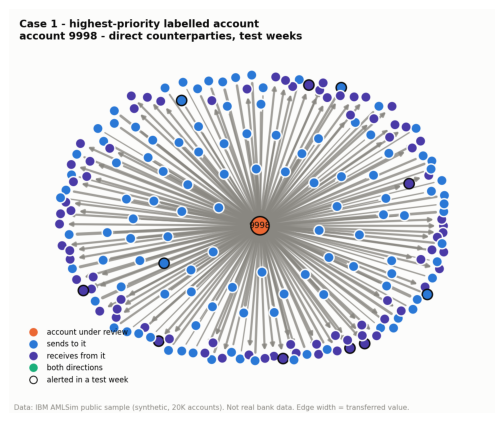

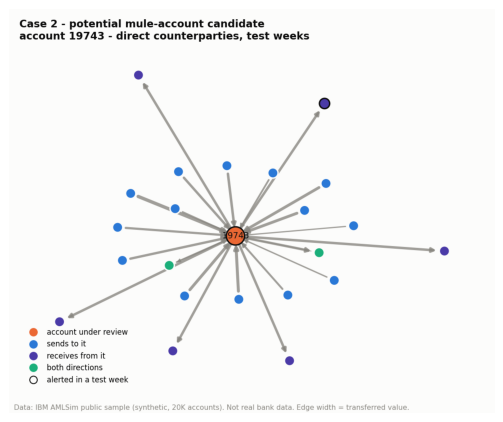

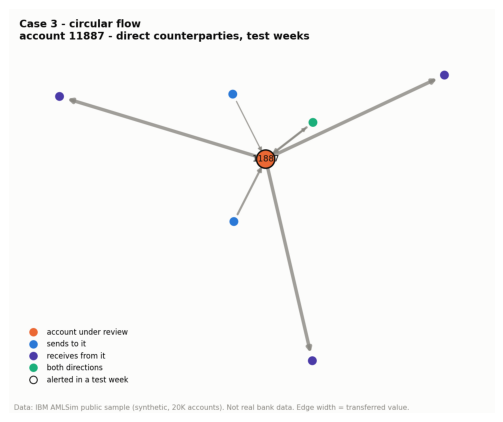

In [10]:
show("fig19_case1_network", 7); show("fig19_case2_network", 7); show("fig19_case3_network", 7)